# Inference & model comparison

**Run order:** `model.ipynb` → `inference.ipynb`

**Samplers:**
- M0/M1 — scalar FFBS (identical to `inference.pdf`)
- M2 — 2-D FFBS on augmented state $X_t=(S_t,S_{t-1})^\top$


In [1]:
import numpy as np
import pandas as pd
import pickle
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import acf


## Load data and models

In [2]:
freq = "seasonal"
df = pd.read_csv(f'../data/covid_{freq}.csv', parse_dates=['date'])
df = df.sort_values(['country', 'date']).reset_index(drop=True)
block_cov = pd.read_csv(f'../data/block_cov_{freq}.csv')
block_cov = block_cov.set_index(['country', 'time_block'])

with open(f'../data/all_models_{freq}.pkl', 'rb') as f:
    all_models = pickle.load(f)

countries    = list(all_models[0]['results'].keys())
MODEL_COLORS = ['#aec7e8', '#1f77b4', '#2ca02c']   # M0, M1, M2
sigma2       = 0.03

print("Loaded models:")
for m in all_models:
    print(f"  {m['label']}  log-ML={m['final_log_ml']:.2f}"
          + (f"  rho={m['rho']:.4f}" if m['rho'] != 0 else ""))


Loaded models:
  M0 — baseline  log-ML=-20538.27
  M1 — +seasonal drift delta_s  log-ML=-18057.90
  M2 — +AR(1) increment  log-ML=-9257.31  rho=0.7709


## Helpers

In [3]:
def get_block_covariates(country, time_block):
    key = (country, time_block)
    if key in block_cov.index:
        return float(block_cov.loc[key,'stringency_lag']), float(block_cov.loc[key,'log_vac_lag'])
    return 0.0, 0.0


def compute_empirical_growth(df_c):
    df_c = df_c.sort_values('date').copy()
    df_c['emp_growth'] = np.exp(df_c['log_cases'].diff())
    return df_c


def compute_model_R(df_c, beta, theta_c, delta=None, sigma2=0.03):
    """
    Model-implied R_t = exp(mu_{t,c} + 0.5*sigma2).
    delta=None for M0; delta=dict for M1/M2.
    """
    U_c1 = float(df_c['pc1'].iloc[0]);  U_c2 = float(df_c['pc2'].iloc[0])
    R = []
    for _, row in df_c.iterrows():
        V_str, V_vac = get_block_covariates(row['country'], row['time_block'])
        X_t = np.array([1., U_c1, U_c2, V_str, V_vac])
        d_s = (delta.get(row['time_block'], np.zeros(5))
               if delta is not None else np.zeros(5))
        mu  = X_t @ (beta + d_s) + theta_c
        R.append(np.exp(mu + 0.5 * sigma2))
    return np.array(R)


## Posterior samplers

In [4]:
# ── Scalar FFBS: M0 / M1 — identical to inference.pdf ────────────────────────
def sample_trajectory(ES, VS, Cov):
    T      = len(ES)
    S      = np.zeros(T)
    S[T-1] = np.random.normal(ES[T-1], np.sqrt(max(VS[T-1], 1e-8)))
    for t in range(T-2, -1, -1):
        J    = Cov[t+1] / VS[t+1]               # no +epsilon: matches inference.pdf
        mean = ES[t] + J * (S[t+1] - ES[t+1])
        var  = max(VS[t] - J * Cov[t+1], 1e-8)  # floor matches inference.pdf
        S[t] = np.random.normal(mean, np.sqrt(var))
    return S


# ── 2-D FFBS: M2 ─────────────────────────────────────────────────────────────
def sample_trajectory_2d(mu_s_2, Sig_s_2, mu_p_2, Sig_p_2, A):
    T      = mu_s_2.shape[0]
    X      = np.zeros((T, 2))
    X[T-1] = np.random.multivariate_normal(mu_s_2[T-1], Sig_s_2[T-1])
    for t in range(T-2, -1, -1):
        Sig_p_inv = np.linalg.pinv(Sig_p_2[t+1] + 1e-10 * np.eye(2))
        G_t       = Sig_s_2[t] @ A.T @ Sig_p_inv
        m_t       = mu_s_2[t] + G_t @ (X[t+1] - mu_p_2[t+1])
        V_t       = Sig_s_2[t] - G_t @ Sig_p_2[t+1] @ G_t.T
        V_t       = (V_t + V_t.T) / 2 + 1e-10 * np.eye(2)
        X[t]      = np.random.multivariate_normal(m_t, V_t)
    return X[:, 0]


def sample_posterior_for_model(m, n_samples=300):
    """
    M0/M1 (delta=None or dict, ar1=False): scalar FFBS — identical to inference.pdf.
    M2 (ar1=True): 2-D FFBS on augmented state.
    Dispatch by m['label'].startswith('M2').
    """
    is_ar1 = m['label'].startswith('M2')
    rho    = m.get('rho', 0.0)
    A      = np.array([[1 + rho, -rho], [1., 0.]])
    out    = {}
    for country in countries:
        res = m['results'][country]
        if is_ar1:
            samples = np.array([
                sample_trajectory_2d(res['mu_s_2'], res['Sig_s_2'],
                                     res['mu_p_2'], res['Sig_p_2'], A)
                for _ in range(n_samples)])
        else:
            ES  = res['ES'];  VS = res['ES2'] - ES**2
            Cov = np.zeros_like(ES);  Cov[1:] = res['ESS'] - ES[1:] * ES[:-1]
            samples = np.array([sample_trajectory(ES, VS, Cov)
                                 for _ in range(n_samples)])
        out[country] = {'S_samples': samples, 'dates': res['dates']}
    return out


## Sample posteriors for all models

In [5]:
N_SAMPLES     = 500
model_samples = {}
for m in all_models:
    print(f"Sampling {m['label']} ...")
    model_samples[m['label']] = sample_posterior_for_model(m, n_samples=N_SAMPLES)
print("Done.")


Sampling M0 — baseline ...
Sampling M1 — +seasonal drift delta_s ...
Sampling M2 — +AR(1) increment ...
Done.


## Plot 1 — Posterior reproduction rate R

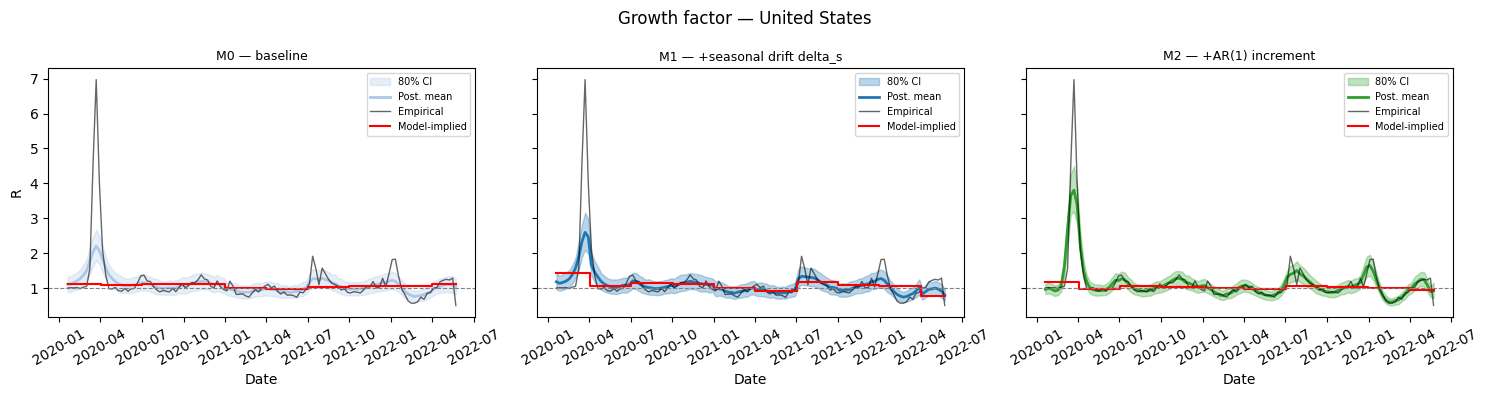

In [6]:
def plot_growth_comparison(country):
    df_c = df[df['country'] == country].sort_values('date').reset_index(drop=True)
    df_c = compute_empirical_growth(df_c)
    emp   = df_c['emp_growth'].values[1:]
    dates = df_c['date'].values[1:]

    fig, axes = plt.subplots(1, len(all_models),
                             figsize=(5 * len(all_models), 4), sharey=True)
    for ax, m, col in zip(axes, all_models, MODEL_COLORS):
        S_samp    = model_samples[m['label']][country]['S_samples']
        R_samples = np.exp(np.diff(S_samp, axis=1))
        post_mean = R_samples.mean(axis=0)
        lower     = np.percentile(R_samples, 10, axis=0)
        upper     = np.percentile(R_samples, 90, axis=0)
        model_R   = compute_model_R(df_c, m['beta'], m['theta'][country],
                                    delta=m['delta'], sigma2=sigma2)[1:]

        ax.fill_between(dates, lower, upper, color=col, alpha=0.3, label='80% CI')
        ax.plot(dates, post_mean, color=col,     lw=2,   label='Post. mean')
        ax.plot(dates, emp,       color='black',  lw=1,   alpha=0.6, label='Empirical')
        ax.step(dates, model_R,   color='red',   lw=1.5, where='mid', label='Model-implied')
        ax.axhline(1, color='gray', linestyle='--', lw=0.8)
        ax.set_title(m['label'], fontsize=9);  ax.set_xlabel('Date')
        ax.tick_params(axis='x', rotation=30)
        if ax is axes[0]: ax.set_ylabel('R')
        ax.legend(fontsize=7)
    fig.suptitle(f'Growth factor — {country}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../data/compare_growth_{country.replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

plot_growth_comparison('United States')


## Plot 2 — Posterior predictive check

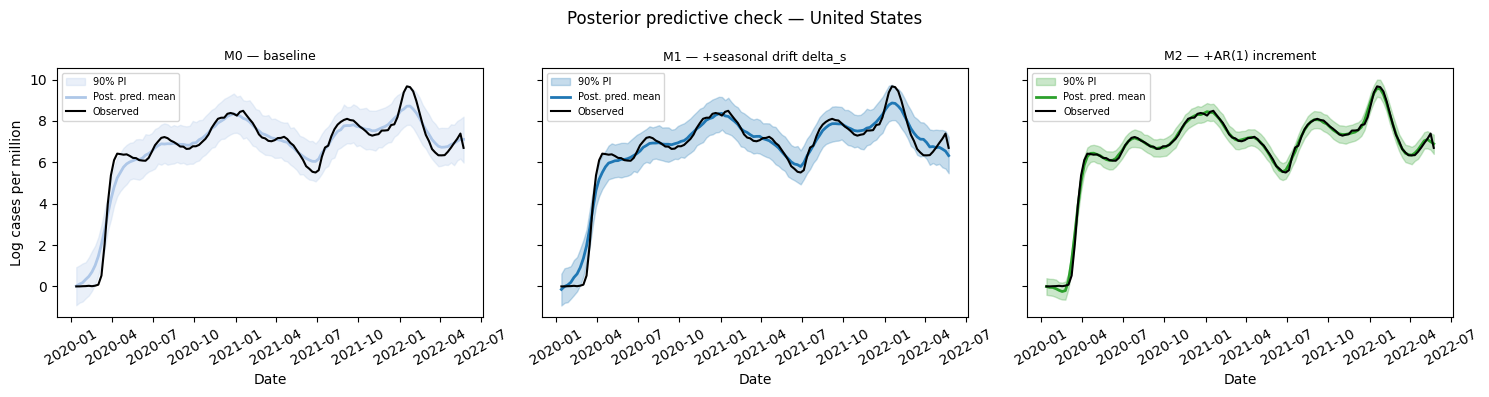

In [7]:
def plot_ppc_comparison(country):
    df_c  = df[df['country'] == country].sort_values('date').reset_index(drop=True)
    Y     = df_c['log_cases'].values
    dates = pd.to_datetime(df_c['date'])

    fig, axes = plt.subplots(1, len(all_models),
                             figsize=(5 * len(all_models), 4), sharey=True)
    for ax, m, col in zip(axes, all_models, MODEL_COLORS):
        S_samp = model_samples[m['label']][country]['S_samples']
        n_s, T = S_samp.shape
        # Y_rep ~ N(S_t + alpha_c, tau2)
        Y_rep  = (S_samp + m['alpha'][country]
                  + np.random.normal(0, np.sqrt(m['tau2']), (n_s, T)))
        ax.fill_between(dates, np.quantile(Y_rep, .05, 0), np.quantile(Y_rep, .95, 0),
                        color=col, alpha=0.25, label='90% PI')
        ax.plot(dates, Y_rep.mean(0), color=col,    lw=2,   label='Post. pred. mean')
        ax.plot(dates, Y,             color='black', lw=1.5, label='Observed')
        ax.set_title(m['label'], fontsize=9);  ax.set_xlabel('Date')
        ax.tick_params(axis='x', rotation=30)
        if ax is axes[0]: ax.set_ylabel('Log cases per million')
        ax.legend(fontsize=7)
    fig.suptitle(f'Posterior predictive check — {country}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../data/compare_ppc_{country.replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

plot_ppc_comparison('United States')


## Plot 3 — Residual ACF

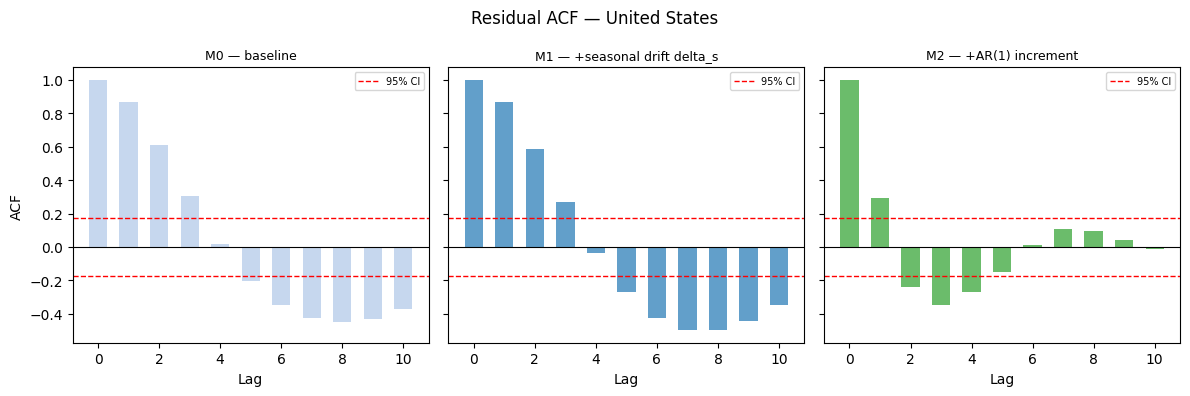

In [8]:
def plot_acf_comparison(country, nlags=10):
    df_c = df[df['country'] == country].sort_values('date').reset_index(drop=True)
    Y    = df_c['log_cases'].values
    ci   = 1.96 / np.sqrt(len(Y))

    fig, axes = plt.subplots(1, len(all_models),
                             figsize=(4 * len(all_models), 4), sharey=True)
    for ax, m, col in zip(axes, all_models, MODEL_COLORS):
        resid    = Y - m['results'][country]['ES']
        acf_vals = acf(resid, nlags=nlags, fft=True)
        ax.bar(range(len(acf_vals)), acf_vals, color=col, alpha=0.7, width=0.6)
        ax.axhline( ci, color='red', linestyle='--', lw=1, label='95% CI')
        ax.axhline(-ci, color='red', linestyle='--', lw=1)
        ax.axhline(0,   color='black', lw=0.8)
        ax.set_title(m['label'], fontsize=9);  ax.set_xlabel('Lag')
        if ax is axes[0]: ax.set_ylabel('ACF')
        ax.legend(fontsize=7)
    fig.suptitle(f'Residual ACF — {country}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../data/compare_acf_{country.replace(" ", "_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()

plot_acf_comparison('United States')


## Plot 4 — Forecast fan

- **M0/M1:** $S_{t+h} = S_{t+h-1} + \mu_{t+h} + \epsilon,\quad\epsilon\sim N(0,\sigma^2)$
- **M2:** $S_{t+h} = (1+\rho)S_{t+h-1} - \rho S_{t+h-2} + \mu_{t+h} + \epsilon$



--- Horizon 1 ---


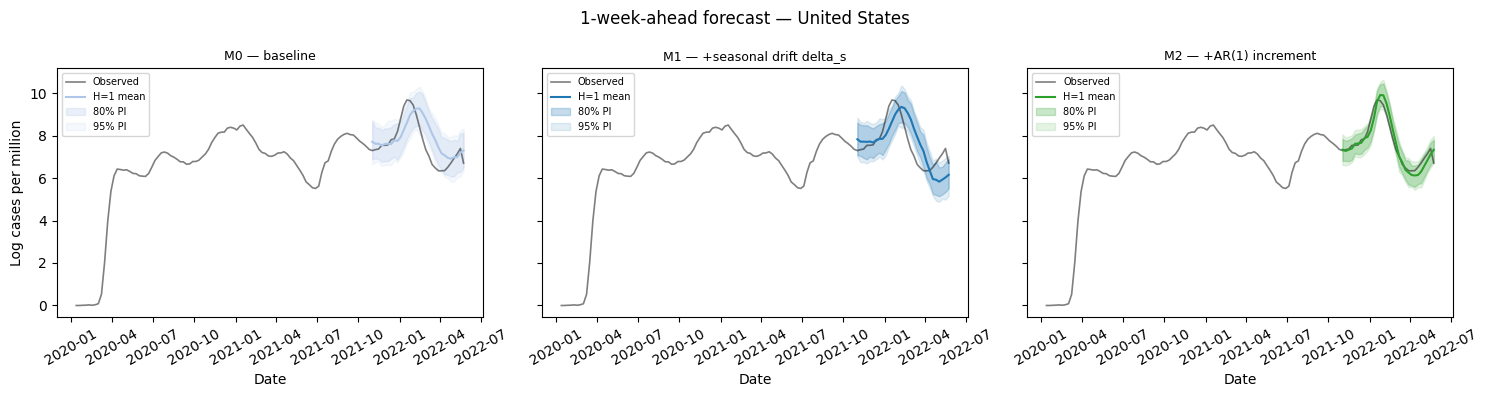


--- Horizon 2 ---


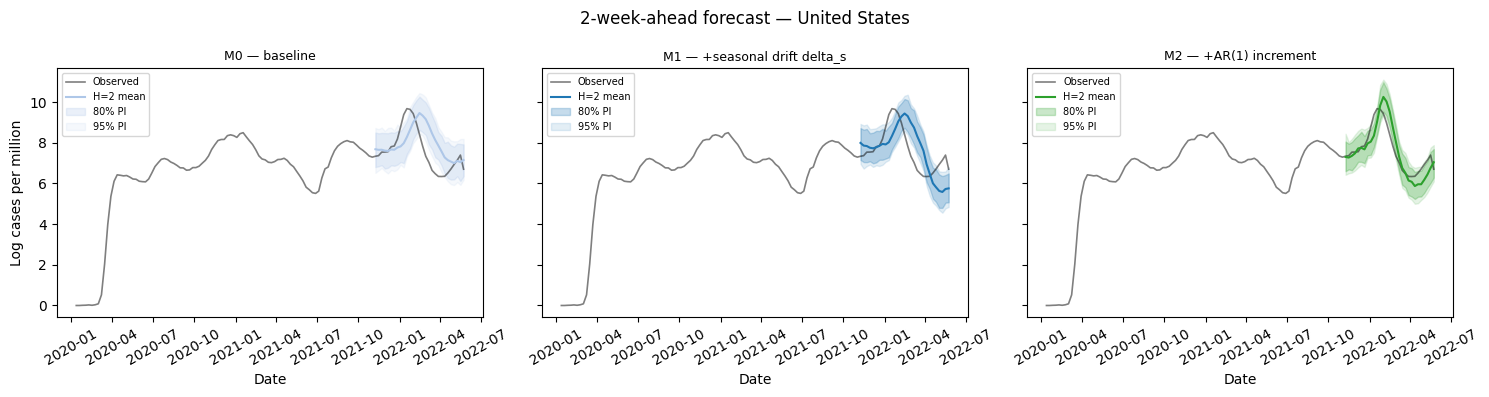


--- Horizon 4 ---


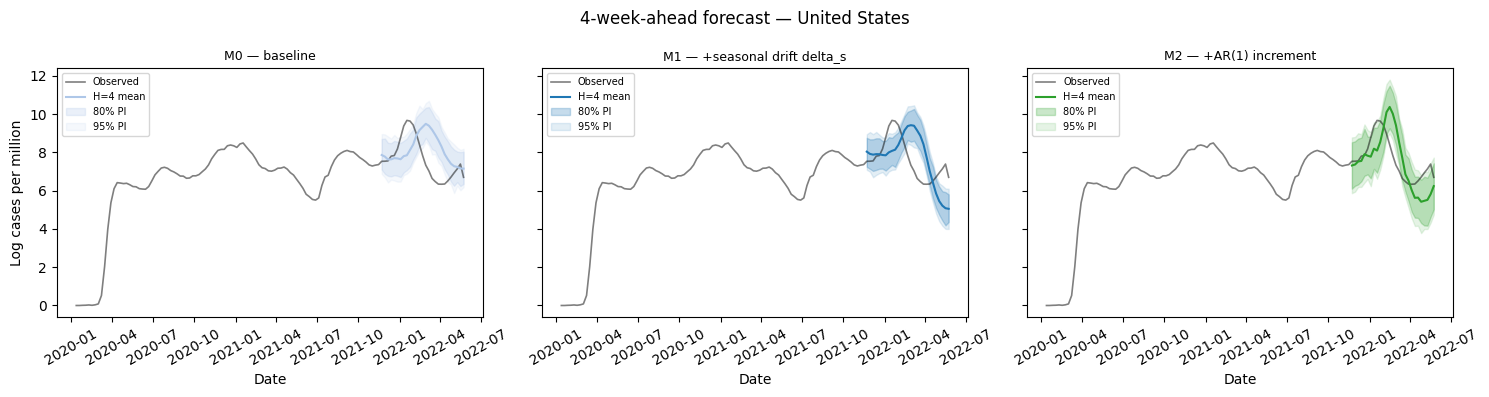


--- Horizon 8 ---


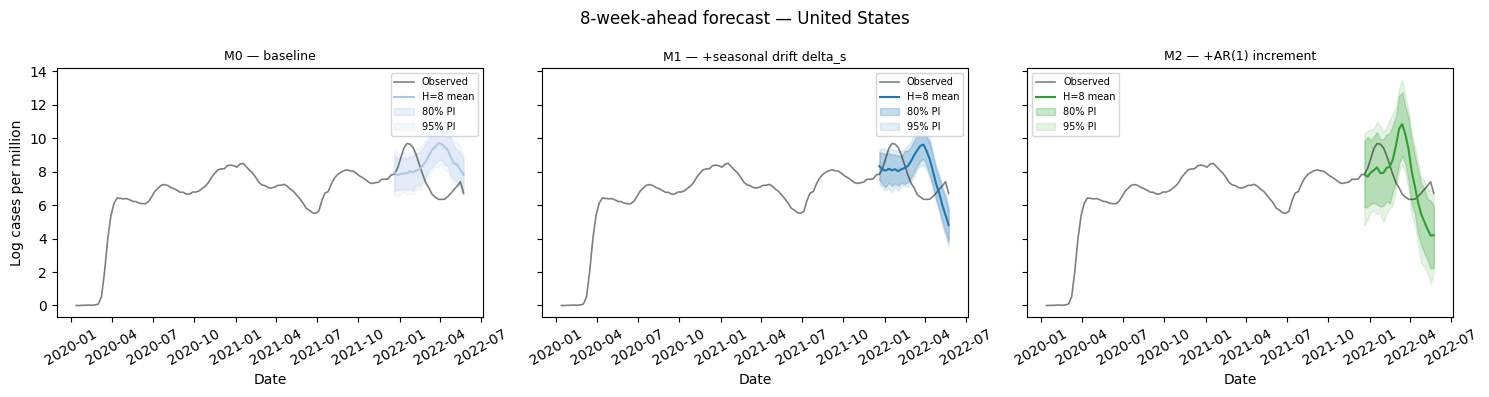

In [9]:
def sample_forecast(S_t, mu_future, alpha_c, tau2, sigma2, H):
    """Scalar (M0/M1) H-step-ahead draw — identical to inference.pdf."""
    S = S_t;  Y_draws = np.empty(H)
    for h in range(H):
        S          = S + mu_future[h] + np.random.normal(0, np.sqrt(sigma2))
        Y_draws[h] = S + alpha_c + np.random.normal(0, np.sqrt(tau2))
    return Y_draws


def sample_forecast_ar1(S_t, S_tm1, mu_future, alpha_c, tau2, sigma2, H, rho):
    """AR(1) (M2) H-step-ahead draw."""
    S_curr = S_t;  S_prev = S_tm1;  Y_draws = np.empty(H)
    for h in range(H):
        S_new      = (1+rho)*S_curr - rho*S_prev + mu_future[h] + np.random.normal(0, np.sqrt(sigma2))
        Y_draws[h] = S_new + alpha_c + np.random.normal(0, np.sqrt(tau2))
        S_prev = S_curr;  S_curr = S_new
    return Y_draws

def draw_starting_state(m, country, t, n_samples):
    """
    Draw starting state at forecast origin t from the filtering distribution.

    M0/M1:
        S_t | Y_0, ..., Y_t

    M2:
        X_t = (S_t, S_{t-1}) | Y_0, ..., Y_t
    """
    res    = m['results'][country]
    is_ar1 = m['label'].startswith('M2')

    if is_ar1:
        mean_t = res['mu_f_2'][t]
        cov_t  = res['Sig_f_2'][t]

        cov_t = (cov_t + cov_t.T) / 2 + 1e-10 * np.eye(2)

        X_t = np.random.multivariate_normal(mean_t, cov_t, size=n_samples)

        # X_t[:, 0] = S_t
        # X_t[:, 1] = S_{t-1}
        return X_t[:, 0], X_t[:, 1]

    else:
        mean_t = res['mu_f'][t]
        var_t  = max(res['Sigma_f'][t], 1e-10)

        S_t_samp = np.random.normal(mean_t, np.sqrt(var_t), size=n_samples)

        return S_t_samp, None

def plot_forecast_comparison(country, horizon=1, n_train_frac=0.75, n_samples=200):
    df_c    = df[df['country'] == country].sort_values('date').reset_index(drop=True)
    Y       = df_c['log_cases'].values.astype(float)
    dates   = df_c['date'].values;  T = len(Y)
    t_start = int(np.floor(n_train_frac * T))

    fig, axes = plt.subplots(1, len(all_models),
                             figsize=(5*len(all_models), 4), sharey=True)
    for ax, m, col in zip(axes, all_models, MODEL_COLORS):
        mu_seq  = m['results'][country]['mu_seq']
        alpha_c = m['alpha'][country]
        is_ar1  = m['label'].startswith('M2')
        rho     = m.get('rho', 0.0)
        records = []
        for t in range(t_start, T - horizon):
            S_t_samp, S_tm1_samp = draw_starting_state(m, country, t, n_samples)
            mu_future = np.array([mu_seq[t+h] if (t+h) < T else 0.
                                   for h in range(1, horizon+1)])
            if is_ar1:
                Y_pred = np.stack([sample_forecast_ar1(S_t_samp[s], S_tm1_samp[s],
                                                       mu_future, alpha_c,
                                                       m['tau2'], sigma2, horizon, rho)
                                   for s in range(n_samples)])
            else:
                Y_pred = np.stack([sample_forecast(S_t_samp[s], mu_future,
                                                   alpha_c, m['tau2'], sigma2, horizon)
                                   for s in range(n_samples)])
            samp = Y_pred[:, horizon-1]
            q05, q10, q90, q95 = np.percentile(samp, [5, 10, 90, 95])
            records.append({'dt': dates[t+horizon], 'mean': samp.mean(),
                            'q05': q05, 'q10': q10, 'q90': q90, 'q95': q95})

        sub = pd.DataFrame(records).sort_values('dt')
        ax.plot(dates, Y, color='black', lw=1.2, alpha=0.5, label='Observed')
        ax.plot(sub['dt'], sub['mean'], color=col, lw=1.5, label=f'H={horizon} mean')
        ax.fill_between(sub['dt'], sub['q10'], sub['q90'], color=col, alpha=0.25, label='80% PI')
        ax.fill_between(sub['dt'], sub['q05'], sub['q95'], color=col, alpha=0.12, label='95% PI')
        ax.set_title(m['label'], fontsize=9);  ax.set_xlabel('Date')
        ax.tick_params(axis='x', rotation=30)
        if ax is axes[0]: ax.set_ylabel('Log cases per million')
        ax.legend(fontsize=7)
    fig.suptitle(f'{horizon}-week-ahead forecast — {country}', fontsize=12)
    plt.tight_layout()
    plt.savefig(f'../data/compare_forecast_h{horizon}_{country.replace(" ","_")}.png',
                dpi=150, bbox_inches='tight')
    plt.show()


COUNTRY  = 'United States'
HORIZONS = [1, 2, 4, 8]
for h in HORIZONS:
    print(f"\n--- Horizon {h} ---")
    plot_forecast_comparison(COUNTRY, horizon=h, n_samples=200)


## Scoring table

In [10]:
rows = []
for i, m in enumerate(all_models):
    rmse_list = [np.sqrt(np.mean((m['results'][c]['Y']
                                  - (m['results'][c]['ES'] + m['alpha'][c]))**2))
                 for c in countries]
    delta_lml = ('—' if i == 0
                 else round(m['final_log_ml'] - all_models[i-1]['final_log_ml'], 2))
    rows.append({
        'Model'        : m['label'],
        'Final log-ML' : round(m['final_log_ml'], 2),
        'Δ log-ML'     : delta_lml,
        'Mean RMSE'    : round(float(np.mean(rmse_list)), 4),
        'tau2'         : round(m['tau2'], 5),
        'rho'          : round(m['rho'], 4),
    })
comp = pd.DataFrame(rows)
print(comp.to_string(index=False))
comp


                       Model  Final log-ML Δ log-ML  Mean RMSE    tau2    rho
               M0 — baseline     -20538.27        —     0.4722 0.27789 0.0000
M1 — +seasonal drift delta_s     -18057.90  2480.37     0.4094 0.21648 0.0000
       M2 — +AR(1) increment      -9257.31  8800.59     0.1553 0.04988 0.7709


,Model,Final log-ML,Δ log-ML,Mean RMSE,tau2,rho
0,M0 — baseline,-20538.27,—,0.4722,0.27789,0.0000
1,M1 — +seasonal drift delta_s,-18057.90,2480.37,0.4094,0.21648,0.0000
2,M2 — +AR(1) increment,-9257.31,8800.59,0.1553,0.04988,0.7709
